# Intro

## Global parameters

In [1]:
MAX_TIME_HOURS=1
ALPHA=0.01
_PVAL_FLOOR=10**-6

## Modules

### Standard

In [2]:
import os, pickle, platform, sys
import numpy as np

In [3]:
from collections import defaultdict

In [4]:
import dcms
from dcms.models import DCMModel, DECMModel, qDECMModel, DWCMModel

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

In [6]:
from scipy.stats import spearmanr

In [7]:
from tqdm.notebook import tqdm, trange

In [8]:
import datetime as dt

In [9]:
from bowtie import edges2bowtie

### Home made

In [10]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")

sys.path.insert(0, HOME)

Air!


In [11]:
from auxiliary_functions import el2ks

In [12]:
from sam_bowtie import block_and_fluxes as bnf

In [13]:
from plot_bowtie import plot_bowtie_blocks, plot_bowtie_fluxes, _add_colorbar
from plot_bowtie import _fdr as fdr

## Load data

In [14]:
DATA_FOLDER=HOME+'dati_elezioni/'
TEST_FOLDER=HOME+'tests/'
PVALUE_FOLDER=HOME+'pvalues/'
GUARINO_FOLDER=HOME+'guarino_files/'
BIPARTITE_FOLDER=HOME+'BiDCM/'
PLOT_FOLDER=HOME+'plots/'

# Looking into the abyss

In [15]:
guarino_files=[file for file in os.listdir(GUARINO_FOLDER) if not file.startswith('.')]
guarino_files.sort()
guarino_files

['all_dico_labels.txt',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'crisi_dico_labels.pickle',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'ita_elections_dico_labels.pickle',
 'quirinale_dico_0_bowtie_sizes.csv',
 'quirinale_dico_1_bowtie_sizes.csv',
 'quirinale_dico_2_bowtie_sizes.csv',
 'quirinale_dico_3_bowtie_sizes.csv',
 'quirinale_dico_4_bowtie_sizes.csv',
 'quirinale_dico_5_bowtie_sizes.csv',
 'quirinale_dico_6_bowtie_sizes.csv',
 'quirinale_dico_labels.pickle']

In [16]:
bipartite_files=[file for file in os.listdir(BIPARTITE_FOLDER) if not file.startswith('.')]
bipartite_files.sort()
bipartite_files

['crisi_dico_0_bowtie_flows.csv',
 'crisi_dico_0_bowtie_sizes.csv',
 'crisi_dico_1_bowtie_flows.csv',
 'crisi_dico_1_bowtie_sizes.csv',
 'crisi_dico_2_bowtie_flows.csv',
 'crisi_dico_2_bowtie_sizes.csv',
 'crisi_dico_3_bowtie_flows.csv',
 'crisi_dico_3_bowtie_sizes.csv',
 'crisi_dico_4_bowtie_flows.csv',
 'crisi_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_0_bowtie_flows.csv',
 'ita_elections_dico_0_bowtie_sizes.csv',
 'ita_elections_dico_1_bowtie_flows.csv',
 'ita_elections_dico_1_bowtie_sizes.csv',
 'ita_elections_dico_2_bowtie_flows.csv',
 'ita_elections_dico_2_bowtie_sizes.csv',
 'ita_elections_dico_3_bowtie_flows.csv',
 'ita_elections_dico_3_bowtie_sizes.csv',
 'ita_elections_dico_4_bowtie_flows.csv',
 'ita_elections_dico_4_bowtie_sizes.csv',
 'ita_elections_dico_5_bowtie_flows.csv',
 'ita_elections_dico_5_bowtie_sizes.csv',
 'ita_elections_dico_6_bowtie_flows.csv',
 'ita_elections_dico_6_bowtie_sizes.csv',
 'quirinale_dico_0_bowtie_flows.csv',
 'quirinale_dico_0_bowtie_sizes.cs

### Name of the various dicos

In [16]:
with open(GUARINO_FOLDER+guarino_files[0], 'r') as f:
    cacca=f.readlines()

In [17]:
cacca

['quirinale\n',
 '5: journalists & Media\n',
 '2: M5S\n',
 '0: journalists & IV & Azione & +Europa & Media\n',
 '4: Lega & FDI\n',
 '1: PD\n',
 '3: Media & journalists\n',
 '6: FI\n',
 '\n',
 'crisi\n',
 '1: Lega & FDI & FI\n',
 '2: M5S & journalists\n',
 '0: journalists & IV & Media & Azione & +Europa\n',
 '4: Media & journalists\n',
 '3: PD\n',
 '\n',
 'ita_elections\n',
 '1: PD & Media & +Europa & journalists\n',
 '2: M5S & Media\n',
 '3: journalists & IV & Azione\n',
 '0: Lega & FDI & FI\n',
 '4: journalists & Media (1)\n',
 '5: Media\n',
 '6: journalists & Media (2)\n',
 '\n']

In [18]:
with open(GUARINO_FOLDER+guarino_files[6], 'rb') as f:
    cacca = pickle.load(f)

In [19]:
cacca

{1: 'Lega & FDI & FI',
 2: 'M5S & journalists',
 0: 'journalists & IV & Media & Azione & +Europa',
 4: 'Media & journalists',
 3: 'PD'}

The pickle is what I need.

# Plots

## Functions

### guarino2lwcc

In [29]:
def guarino2lwcc(dataset, dico):
    # get the file
    file_name=f'{dataset}_dico_{dico}_bowtie_sizes.csv'
    # load the data
    cacca=np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=int, skip_header=1)
    header = np.genfromtxt(BIPARTITE_FOLDER+file_name, delimiter=',', dtype=str, max_rows=1)
    header=[str(h) for h in header]
    n_sample=cacca.shape[0]
    n_lwcc=np.zeros(n_sample, dtype=int)
   
    for i, name in enumerate(header):
        n_lwcc+=cacca[:,i]
    return n_lwcc



## Italian elections

### Prelude

In [21]:
labels_file=[file for file in os.listdir(GUARINO_FOLDER) if file.endswith('.pickle') and file.startswith('ita')][0]

In [22]:
labels=pickle.load(open(GUARINO_FOLDER+labels_file, 'rb'))

In [23]:
labels

{1: 'PD & Media & +Europa & journalists',
 2: 'M5S & Media',
 3: 'journalists & IV & Azione',
 0: 'Lega & FDI & FI',
 4: 'journalists & Media (1)',
 5: 'Media',
 6: 'journalists & Media (2)'}

### Right-wing

In [24]:
dataset='ita_elections'
dico=0

In [32]:
bipartite_lwcc=guarino2lwcc(dataset, dico)

In [35]:
pvalue_lwcc_filename=PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_lwcc.pkl'
with open(pvalue_lwcc_filename, 'rb') as f:
    monopartite_lwcc_dict=pickle.load(f)
                    

In [37]:
monopartite_lwcc=monopartite_lwcc_dict['count_sample']
obs_lwcc=monopartite_lwcc_dict['obs']

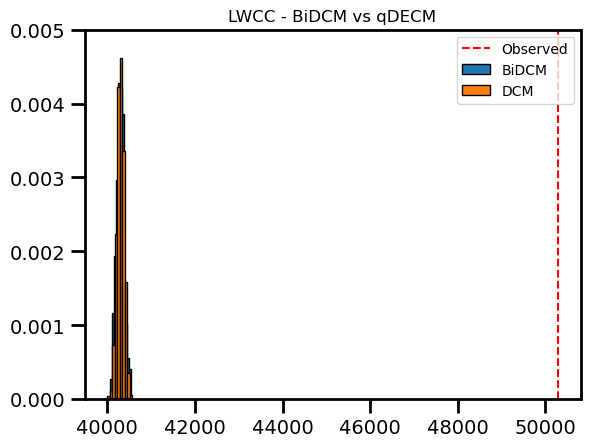

In [43]:

plt.vlines(obs_lwcc, ymin=0, ymax=1, color='red', linestyle='--', label='Observed')
plt.hist(bipartite_lwcc, edgecolor='black', density=True, label='BiDCM')
plt.hist(monopartite_lwcc, edgecolor='black', density=True, label='DCM')
#x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
#plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
#plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 5*10**-3)
plt.title('LWCC - BiDCM vs qDECM')
plt.legend()
plt.show()

### Italia Viva & Azione

In [44]:
dataset='ita_elections'
dico=3

In [45]:
bipartite_lwcc=guarino2lwcc(dataset, dico)

In [46]:
pvalue_lwcc_filename=PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_lwcc.pkl'
with open(pvalue_lwcc_filename, 'rb') as f:
    monopartite_lwcc_dict=pickle.load(f)
                    

In [47]:
monopartite_lwcc=monopartite_lwcc_dict['count_sample']
obs_lwcc=monopartite_lwcc_dict['obs']

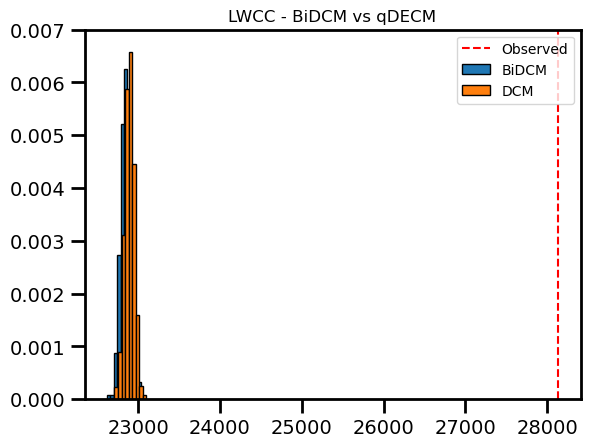

In [50]:

plt.vlines(obs_lwcc, ymin=0, ymax=1, color='red', linestyle='--', label='Observed')
plt.hist(bipartite_lwcc, edgecolor='black', density=True, label='BiDCM')
plt.hist(monopartite_lwcc, edgecolor='black', density=True, label='DCM')
#x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
#plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
#plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 7*10**-3)
plt.title('LWCC - BiDCM vs qDECM')
plt.legend()
plt.show()

### PD

In [51]:
dataset='ita_elections'
dico=1

In [52]:
bipartite_lwcc=guarino2lwcc(dataset, dico)

In [53]:
pvalue_lwcc_filename=PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_lwcc.pkl'
with open(pvalue_lwcc_filename, 'rb') as f:
    monopartite_lwcc_dict=pickle.load(f)
                    

In [54]:
monopartite_lwcc=monopartite_lwcc_dict['count_sample']
obs_lwcc=monopartite_lwcc_dict['obs']

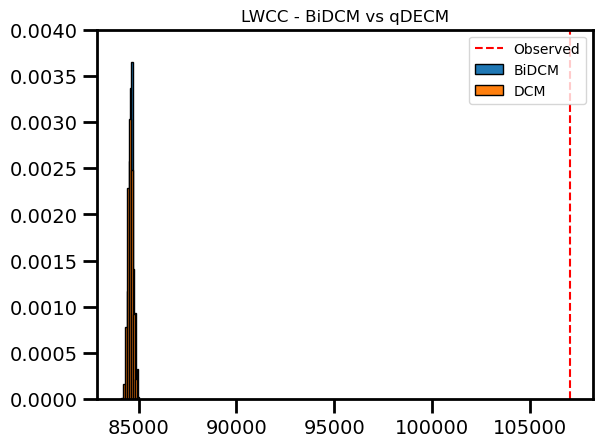

In [56]:

plt.vlines(obs_lwcc, ymin=0, ymax=1, color='red', linestyle='--', label='Observed')
plt.hist(bipartite_lwcc, edgecolor='black', density=True, label='BiDCM')
plt.hist(monopartite_lwcc, edgecolor='black', density=True, label='DCM')
#x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
#plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
#plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 4*10**-3)
plt.title('LWCC - BiDCM vs qDECM')
plt.legend()
plt.show()

### M5S

In [57]:
dataset='ita_elections'
dico=2

In [58]:
bipartite_lwcc=guarino2lwcc(dataset, dico)

In [59]:
pvalue_lwcc_filename=PVALUE_FOLDER+f'{dataset}_dico{dico}_pvalues_lwcc.pkl'
with open(pvalue_lwcc_filename, 'rb') as f:
    monopartite_lwcc_dict=pickle.load(f)
                    

In [60]:
monopartite_lwcc=monopartite_lwcc_dict['count_sample']
obs_lwcc=monopartite_lwcc_dict['obs']

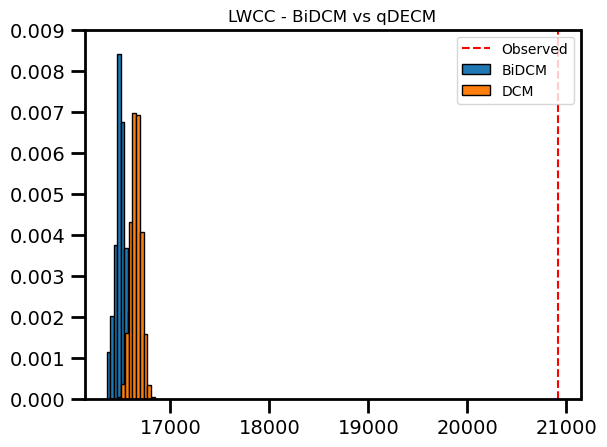

In [65]:

plt.vlines(obs_lwcc, ymin=0, ymax=1, color='red', linestyle='--', label='Observed')
plt.hist(bipartite_lwcc, edgecolor='black', density=True, label='BiDCM')
plt.hist(monopartite_lwcc, edgecolor='black', density=True, label='DCM')
#x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
#plt.plot(x, norm.pdf(x, mu, sig), color='orange', label='qDECM', linewidth=3)
#plt.fill_between(x, norm.pdf(x, mu, sig), alpha=0.3, color='orange')
plt.ylim(0, 9*10**-3)
plt.title('LWCC - BiDCM vs qDECM')
plt.legend()
plt.show()

# Summary and next steps 
As we are focusing on communities, I expected that they would reproduce a LWCC and, therefore, in the sample the LWCC would have been much smaller. Nevertheless, it is always statistically significant for both models, which is non-trivial, at first sight. Still, as the most definitive blocks are mostly significant on the right side of the distribution, it means that we are cutting out limitedly interacting nodes, thus none really gets hurted. But so, it only makes sense to test only on the right tail, as our models predict smaller bowties: in this sense, their contribution is much higher than expected. So, it seems that the Guarino's normalization is the most sensed one among all. Or not? Is it introducing a bias?